# Climate Change Tipping Point Proximity Tracker

This project tracks how close Earth's major climate systems are to irreversible tipping points, using NASA, NOAA, and NSIDC data.

**Research question:** At current warming, how close are we to crossing climate tipping points, and how fast are we approaching them?

**Datasets**
| Dataset | Source | Coverage |
|---|---|---|
| Global temperature anomaly | NASA GISS | 1880 – present |
| Atmospheric CO₂ | NOAA Mauna Loa | 1958 – present |
| Arctic sea ice extent | Our World in Data / NSIDC | 1980 – present |

**Tipping point thresholds:** Armstrong McKay et al. (2022), *Science*, Vol. 377, Table 1. DOI: 10.1126/science.abn7950

### Libraries & Data

In [1]:
# import libraries
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from IPython.display import display, Markdown

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('coolwarm')

MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok = True)

def cached_download(url, filename, refresh = False):
    """Fetch `url` into data/<filename> on first run; reuse the local copy thereafter."""
    path = DATA_DIR / filename
    if refresh or not path.exists():
        req = urllib.request.Request(url, headers = {'User-Agent': 'climate-tipping-notebook/1.0'})
        with urllib.request.urlopen(req) as response, open(path, 'wb') as f:
            f.write(response.read())
        print(f"Downloaded {filename} ({path.stat().st_size:,} bytes)")
    else:
        retrieved = pd.Timestamp(path.stat().st_mtime, unit = 's').strftime('%Y-%m-%d')
        print(f"Using cached {filename} (retrieved {retrieved})")
    return path

In [2]:
# load global temperature data
GISTEMP_URL = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
temp_df = pd.read_csv(cached_download(GISTEMP_URL, 'global_temp.csv'), skiprows = 1, na_values = ['***'])

assert set(MONTHS).issubset(temp_df.columns), 'GISTEMP layout changed, check the header row'
temp_df = temp_df[['Year'] + MONTHS]

# melt from wide to long format
temp_long = temp_df.melt(id_vars = 'Year', var_name = 'Month', value_name = 'anomaly_C')
temp_long['date'] = pd.to_datetime(
    temp_long['Year'].astype(str) + '-' + temp_long['Month'],
    format = '%Y-%b'
)
temp_long = temp_long.dropna().sort_values('date').reset_index(drop = True)

print(f"{len(temp_long)} monthly records, ranging from year {temp_long['date'].min().year} to {temp_long['date'].max().year}.")
temp_long.tail()

Using cached global_temp.csv (retrieved 2026-08-08)
1758 monthly records, ranging from year 1880 to 2026.


,Year,Month,anomaly_C,date
1753,2026,Feb,1.25,2026-02-01
1754,2026,Mar,1.32,2026-03-01
1755,2026,Apr,1.17,2026-04-01
1756,2026,May,1.13,2026-05-01
1757,2026,Jun,1.18,2026-06-01


In [3]:
# load CO₂ data from NOAA Mauna Loa (updated monthly)
CO2_URL = 'https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv'
co2_df = pd.read_csv(cached_download(CO2_URL, 'co2_mm_mlo.csv'), comment = '#')

assert {'year', 'month', 'average'}.issubset(co2_df.columns), \
    f'NOAA layout changed: {list(co2_df.columns)}'

co2_df['date'] = pd.to_datetime(co2_df[['year', 'month']].assign(day = 1))
co2_df = co2_df[['date', 'average']].rename(columns = {'average': 'co2_ppm'})
co2_df = co2_df[co2_df['co2_ppm'] > 0].reset_index(drop = True)   # NOAA uses -99.99 for missing

print(f"{len(co2_df)} monthly records, {co2_df['date'].min():%Y-%m} to {co2_df['date'].max():%Y-%m}")
co2_df.tail()

Using cached co2_mm_mlo.csv (retrieved 2026-08-08)
821 monthly records, 1958-03 to 2026-07


,date,co2_ppm
816,2026-03-01,430.15
817,2026-04-01,431.12
818,2026-05-01,432.34
819,2026-06-01,431.44
820,2026-07-01,429.12


In [4]:
# load sea ice data
ICE_URL = ("https://ourworldindata.org/grapher/monthly-sea-ice-extent-in-the-arctic.csv"
           "?v=1&csvType=full&useColumnShortNames=false")
ice_df = pd.read_csv(cached_download(ICE_URL, 'arctic_sea_ice.csv'))

print(ice_df.tail())
print(ice_df.nunique())

Using cached arctic_sea_ice.csv (retrieved 2026-08-08)
     Entity  Year  Monthly sea ice extent in the Arctic
551    2026     2                                14.098
552    2026     3                                14.131
553    2026     4                                13.568
554    2026     5                                12.140
555    2026     6                                10.422
Entity                                   47
Year                                     12
Monthly sea ice extent in the Arctic    543
dtype: int64


Note: upon inspection, the `Entity` column holds the year and the `Year` column holds the month. Renaming them below.

In [5]:
# correct column names
ice_df = ice_df.rename(columns = {
    'Entity': 'year',
    'Year': 'month',
    'Monthly sea ice extent in the Arctic': 'extent_mkm2'
})

ice_df['month_name'] = ice_df['month'].apply(lambda m: MONTHS[m - 1])

ice_df.tail()

,year,month,extent_mkm2,month_name
551,2026,2,14.098,Feb
552,2026,3,14.131,Mar
553,2026,4,13.568,Apr
554,2026,5,12.140,May
555,2026,6,10.422,Jun


### EDA & Visualizations

In [6]:
# NASA GISS anomalies are relative to 1951–1980
# Armstrong McKay et al. thresholds are relative to 1850–1900
# re-reference the series to the earliest available window (1880–1899)
PI_BASELINE = temp_long[temp_long['Year'].between(1880, 1899)]['anomaly_C'].mean()
temp_long['anomaly_pi'] = temp_long['anomaly_C'] - PI_BASELINE

month_counts = temp_long.groupby('Year').size()
complete_years = month_counts[month_counts == 12].index

annual_temp = (
    temp_long[temp_long['Year'].isin(complete_years)]
    .groupby('Year')['anomaly_pi']
    .mean()
    .reset_index()
)
annual_temp.columns = ['year', 'anomaly_C']   # now referenced to pre-industrial

# "Current warming" follows the IPCC AR6 convention of a 20-year mean.
WINDOW_YEARS = 20
current_temp = annual_temp['anomaly_C'].tail(WINDOW_YEARS).mean()
current_temp_2yr = annual_temp['anomaly_C'].tail(2).mean()
current_co2 = co2_df['co2_ppm'].iloc[-1]

print(f"GISS baseline offset (1880–1899 vs 1951–1980): {PI_BASELINE:+.3f}°C")
print(f"Current warming, {WINDOW_YEARS}-yr mean (IPCC convention): +{current_temp:.2f}°C")
print(f"  sensitivity, 2-yr mean instead:  +{current_temp_2yr:.2f}°C "
      f"({current_temp_2yr - current_temp:+.2f}°C vs the 20-yr figure)")
print(f"Latest CO₂ reading: {current_co2:.1f} ppm")
print('Pre-industrial CO₂ baseline: ~280 ppm')
print(f"CO₂ increase since industrialization: +{current_co2 - 280:.1f} ppm")

GISS baseline offset (1880–1899 vs 1951–1980): -0.227°C
Current warming, 20-yr mean (IPCC convention): +1.07°C
  sensitivity, 2-yr mean instead:  +1.46°C (+0.39°C vs the 20-yr figure)
Latest CO₂ reading: 429.1 ppm
Pre-industrial CO₂ baseline: ~280 ppm
CO₂ increase since industrialization: +149.1 ppm


In [7]:
# 10-year rolling mean, for the chart below
annual_temp['rolling_10yr'] = annual_temp['anomaly_C'].rolling(10, center = True).mean()

# post-1980 only, where the warming trend steepens
recent_temp = annual_temp[annual_temp['year'] >= 1980]
y_obs = recent_temp['anomaly_C'].to_numpy(dtype = float)
X_obs = sm.add_constant(recent_temp['year'].to_numpy(dtype = float))

ols = sm.OLS(y_obs, X_obs).fit()

# Annual temperature residuals are serially correlated, one warm year makes the
# next more likely, which violates the independence assumption behind the OLS
# standard error. Newey–West (HAC) relaxes it. maxlags follows the standard
# 4(T/100)^(2/9) rule of thumb.
T = len(y_obs)
maxlags = int(np.floor(4 * (T / 100) ** (2 / 9)))
hac = sm.OLS(y_obs, X_obs).fit(cov_type = 'HAC', cov_kwds = {'maxlags' : maxlags})

intercept, slope = hac.params
stderr = hac.bse[1]    # HAC standard error on the slope, used downstream
stderr_ols = ols.bse[1]    # naive OLS standard error, for comparison
r = np.sqrt(ols.rsquared)
warming_per_year = slope

# Durbin-Watson below 2 means positively autocorrelated residuals, which is
# what makes the OLS standard error too narrow here
dw = durbin_watson(ols.resid)

def crossing_year(target):
    """Year at which the post-1980 linear trend reaches `target` °C."""
    return (target - intercept) / slope

print(f"Warming rate (post-1980 trend): +{warming_per_year:.4f} °C per year")
print(f"  HAC (Newey–West, maxlags={maxlags}) SE: ±{stderr:.4f}")
print(f"  naive OLS SE: ±{stderr_ols:.4f}"
      f"   (HAC is {stderr / stderr_ols:.2f}x the OLS figure)")
print(f"  Durbin-Watson {dw:.2f}, so residuals are positively autocorrelated and "
      f"so the OLS standard error is too narrow")
print(f"R²: {r ** 2:.3f}")
print(f"At this rate, +1.5°C reached around: {crossing_year(1.5):.0f}")
print(f"At this rate, +2.0°C reached around: {crossing_year(2.0):.0f}")

Warming rate (post-1980 trend): +0.0208 °C per year
  HAC (Newey–West, maxlags=3) SE: ±0.0017
  naive OLS SE: ±0.0012   (HAC is 1.42x the OLS figure)
  Durbin-Watson 1.20, so residuals are positively autocorrelated and so the OLS standard error is too narrow
R²: 0.873
At this rate, +1.5°C reached around: 2036
At this rate, +2.0°C reached around: 2060


#### Global temperature anomaly

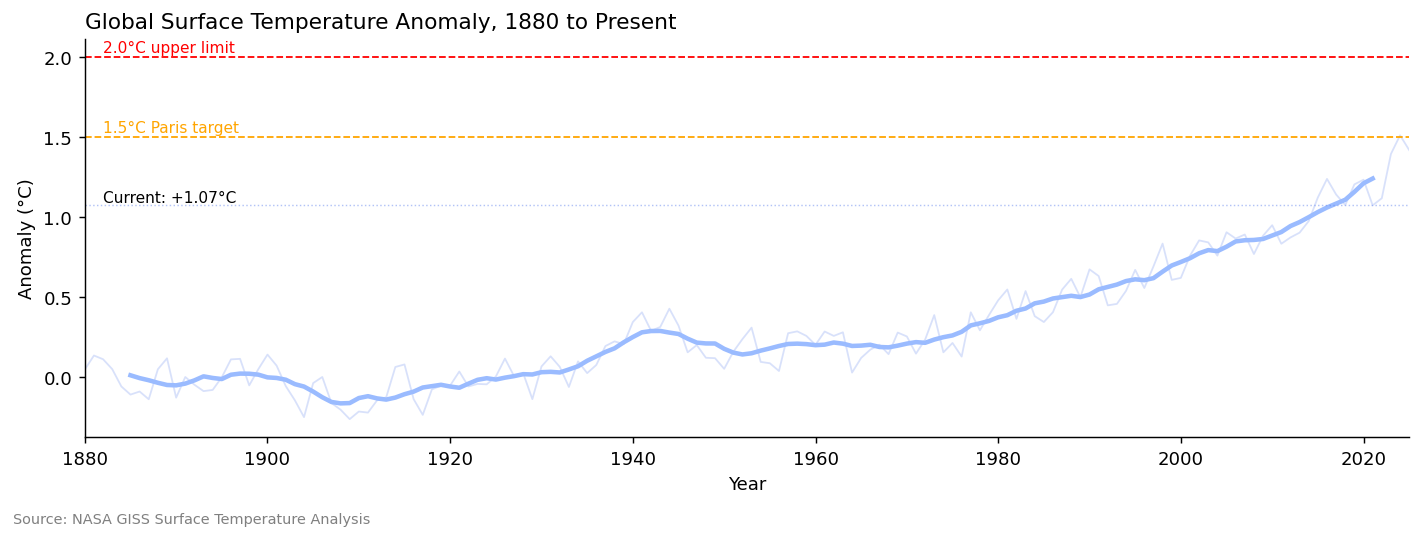

In [8]:
fig, ax = plt.subplots(figsize = (11, 4))

ax.plot(annual_temp['year'], annual_temp['anomaly_C'], alpha = 0.25, linewidth = 1)
ax.plot(annual_temp['year'], annual_temp['rolling_10yr'], linewidth = 2.5, label = '10-year average')

ax.axhline(1.5, color = 'orange', linewidth = 1, linestyle = '--')
ax.axhline(2.0, color = 'red', linewidth = 1, linestyle = '--')
ax.text(1882, 1.53, '1.5°C Paris target', color = 'orange', fontsize = 8.5)
ax.text(1882, 2.03, '2.0°C upper limit', color = 'red', fontsize = 8.5)
ax.text(1882, current_temp + 0.02, f'Current: +{current_temp:.2f}°C', fontsize = 8.5)
ax.axhline(current_temp, linewidth = 0.8, linestyle = ':', alpha = 0.5)

ax.set_xlabel('Year')
ax.set_ylabel('Anomaly (°C)')
ax.set_title('Global Surface Temperature Anomaly, 1880 to Present', loc = 'left')
ax.set_xlim(annual_temp['year'].min(), annual_temp['year'].max())

plt.figtext(0.01, -0.02, 'Source: NASA GISS Surface Temperature Analysis', fontsize = 8, color = 'gray')
plt.tight_layout()
plt.show()

In [9]:
decade_rate = warming_per_year * 10
gap_15 = 1.5 - current_temp
paris_status = ("has already passed the 1.5\u00b0C Paris Agreement target"
                if gap_15 <= 0 else
                f"sits {gap_15:.2f}\u00b0C below the 1.5\u00b0C Paris Agreement target")

Markdown(f"""
Earth has warmed **+{current_temp:.2f}\u00b0C** since pre-industrial (1880\u20131899 baseline). The bold
curve is a 10-year rolling mean smoothing out El Ni\u00f1o/La Ni\u00f1a swings. Warming steepened after
1980, running at **+{decade_rate:.2f} \u00b1 {stderr * 10:.2f}\u00b0C per decade** (R\u00b2 = {r**2:.2f}), with
a Newey\u2013West standard error accounting for serial correlation in the residuals.

The current {WINDOW_YEARS}-year average {paris_status}. Extending the post-1980 trend, +1.5\u00b0C
arrives around **{crossing_year(1.5):.0f}**, +2.0\u00b0C around **{crossing_year(2.0):.0f}**.
""")


Earth has warmed **+1.07°C** since pre-industrial (1880–1899 baseline). The bold
curve is a 10-year rolling mean smoothing out El Niño/La Niña swings. Warming steepened after
1980, running at **+0.21 ± 0.02°C per decade** (R² = 0.87), with
a Newey–West standard error accounting for serial correlation in the residuals.

The current 20-year average sits 0.43°C below the 1.5°C Paris Agreement target. Extending the post-1980 trend, +1.5°C
arrives around **2036**, +2.0°C around **2060**.


#### CO₂ Keeling Curve

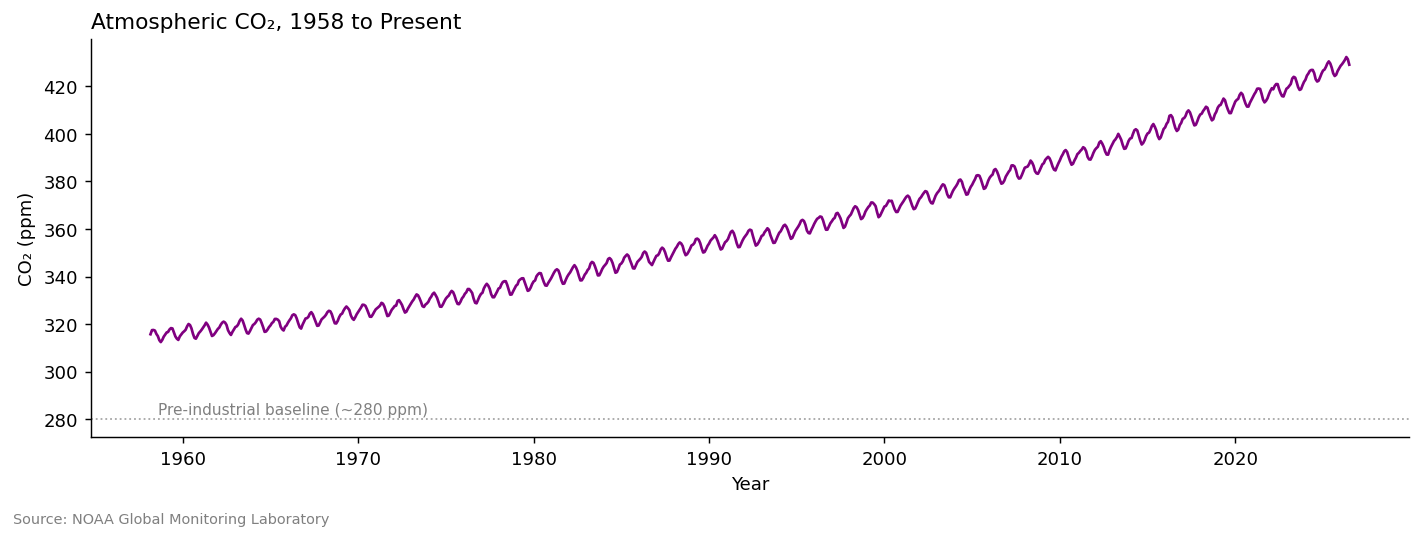

In [10]:
fig, ax = plt.subplots(figsize = (11, 4))

ax.plot(co2_df['date'], co2_df['co2_ppm'], color = 'purple', linewidth = 1.5)
ax.axhline(280, color = 'gray', linestyle = ':', linewidth = 1, alpha = 0.7)
ax.text(co2_df['date'].iloc[5], 282, 'Pre-industrial baseline (~280 ppm)', color = 'gray', fontsize = 8.5)
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Atmospheric CO₂, 1958 to Present', loc = 'left')

plt.figtext(0.01, -0.02, 'Source: NOAA Global Monitoring Laboratory', fontsize = 8, color = 'gray')
plt.tight_layout()
plt.show()

In [11]:
co2_start = co2_df['co2_ppm'].iloc[0]
co2_pct = (current_co2 - 280) / 280 * 100

Markdown(f"""
Atmospheric CO\u2082 has risen from **{co2_start:.0f} ppm** in 1958 (Mauna Loa measurements began)
to **{current_co2:.0f} ppm** today, {co2_pct:.0f}% above pre-industrial (~280 ppm). The sawtooth
is Northern Hemisphere vegetation: CO\u2082 dips each summer as plants take it up, then climbs back
over winter.
""")


Atmospheric CO₂ has risen from **316 ppm** in 1958 (Mauna Loa measurements began)
to **429 ppm** today, 53% above pre-industrial (~280 ppm). The sawtooth
is Northern Hemisphere vegetation: CO₂ dips each summer as plants take it up, then climbs back
over winter.


#### Arctic Sea Ice Extent By Month

In [12]:
# set ranges for consistency
y_min = ice_df['extent_mkm2'].min() - 0.5
y_max = ice_df['extent_mkm2'].max() + 0.5
x_min = ice_df['year'].min() - 1
x_max = ice_df['year'].max() + 1

# radio buttons for month selection
month_select = alt.binding_radio(options = MONTHS, name = 'Month: ')
month_param = alt.param(name = 'selected_month', value = 'Sep', bind = month_select)

points = alt.Chart(ice_df).mark_circle(
    size = 50,
    color = 'blue',
    opacity = 0.7
).encode(
    x = alt.X('year:Q',
              title = 'Year',
              axis = alt.Axis(format = 'd', tickCount = 8, labelAngle = 0),
              scale = alt.Scale(domain = [x_min, x_max])),
    y = alt.Y('extent_mkm2:Q',
              title = 'Extent (million km²)',
              scale = alt.Scale(domain = [y_min, y_max])),
    tooltip = [
        alt.Tooltip('year:Q', title = 'Year'),
        alt.Tooltip('month_name:N', title = 'Month'),
        alt.Tooltip('extent_mkm2:Q', title = 'Extent (M km²)', format = '.2f')
    ]
).transform_filter(
    alt.datum.month_name == month_param
).add_params(month_param)

trend = alt.Chart(ice_df).mark_line(
    color = 'red',
    strokeDash = [6, 4],
    strokeWidth = 2
).encode(
    x = alt.X('year:Q', scale = alt.Scale(domain = [x_min, x_max])),
    y = alt.Y('extent_mkm2:Q', scale = alt.Scale(domain = [y_min, y_max]))
).transform_filter(
    alt.datum.month_name == month_param
).transform_regression(
    'year', 'extent_mkm2', method = 'linear'
)

# use sept as reference
sept_avg = ice_df[ice_df['month_name'] == 'Sep']['extent_mkm2'].mean()

sept_line = alt.Chart(
    alt.InlineData(values = [{'y': sept_avg}])
).mark_rule(
    color = 'gray',
    strokeDash = [4, 4],
    strokeWidth = 1,
    opacity = 0.5
).encode(
    y = alt.Y('y:Q', scale = alt.Scale(domain = [y_min, y_max])),
    tooltip = [alt.Tooltip('y:Q', title = 'Sep avg', format = '.2f')]
)

sept_label = alt.Chart(
    alt.InlineData(values = [{'y': sept_avg, 'x': x_min + 1}])
).mark_text(
    align = 'left',
    dy = -8,
    fontSize = 11,
    color = 'gray',
    fontStyle = 'italic'
).encode(
    x = alt.X('x:Q'),
    y = alt.Y('y:Q'),
    text = alt.value('Sep avg (reference)')
)

chart = (points + trend + sept_line + sept_label).properties(
    width = 580,
    height = 340,
    title = alt.TitleParams(
        text = 'Arctic Sea Ice Extent by Month',
        subtitle = ['Red dashed line shows long-term trend. Gray line marks September average for reference.'],
        fontSize = 15,
        fontWeight = 'normal',
        subtitleFontSize = 11,
        subtitleColor = 'gray',
        anchor = 'start',
        dy = -8
    )
)

chart

alt.LayerChart(...)

In [13]:
sept_ice = ice_df[ice_df['month_name'] == 'Sep'].copy()

# Largest k for which the k most recent Septembers are also the k lowest on
# record, self-computing, so the claim is exactly as strong as the data allows.
ordered = sept_ice.sort_values('year')
ranks = ordered['extent_mkm2'].rank().to_numpy()
k = max((kk for kk in range(1, len(ranks) + 1)
         if set(ranks[-kk:]) == set(range(1, kk + 1))), default = 0)
since = int(ordered['year'].iloc[-k]) if k else None

streak_txt = (f"Every September since {since} ranks among the {k} lowest in the "
              f"{len(sept_ice)}-year record."
              if k > 1 else
              "The most recent Septembers are among the lowest in the record.")

Markdown(f"""
##### Why September?
Arctic sea ice grows and shrinks every year. Plotting all 12 months together lets that
seasonal swing bury the long-term decline.

September is the standard benchmark:
1. End of the melt season, so the decline shows up most clearly there.
2. It's the metric the tipping point concerns: an ice-free Arctic summer, not winter ice.
3. IPCC and NASA both use it, keeping this comparable to published work.

{streak_txt} Use the radio buttons above to switch months; the decline shows up in nearly
every month, clearest in summer.
""")


##### Why September?
Arctic sea ice grows and shrinks every year. Plotting all 12 months together lets that
seasonal swing bury the long-term decline.

September is the standard benchmark:
1. End of the melt season, so the decline shows up most clearly there.
2. It's the metric the tipping point concerns: an ice-free Arctic summer, not winter ice.
3. IPCC and NASA both use it, keeping this comparable to published work.

Every September since 2007 ranks among the 19 lowest in the 46-year record. Use the radio buttons above to switch months; the decline shows up in nearly
every month, clearest in summer.


#### September sea ice decline with linear projection

linear decline: -0.777 million km² per decade (adjusted r² 0.799)
acceleration test: squared term p = 0.783, adjusted r² 0.799 -> 0.794
  -> acceleration not supported; keeping the linear fit


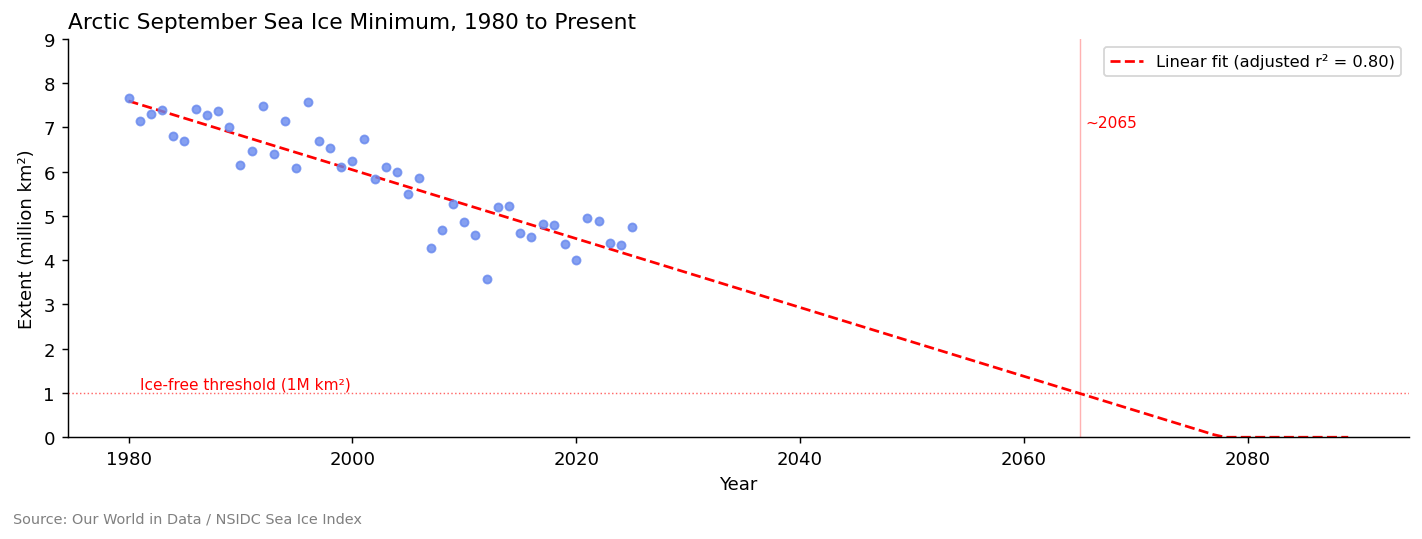

In [14]:
# Center the year. Fitting on raw years puts year² near 4e6 and the design
# matrix condition number around 1e11; centering brings it to ~3e3.
t0 = int(sept_ice['year'].min())
t = sept_ice['year'].to_numpy(dtype = float) - t0
y_ice = sept_ice['extent_mkm2'].to_numpy(dtype = float)

# Same HAC treatment as the temperature trend, for the same reason: sea ice
# residuals are serially correlated, so plain OLS inference is overconfident.
ice_lags = int(np.floor(4 * (len(y_ice) / 100) ** (2 / 9)))
fit_lin = sm.OLS(y_ice, sm.add_constant(t)).fit(
    cov_type = 'HAC', cov_kwds = {'maxlags': ice_lags})

# The ice-albedo feedback predicts the decline should accelerate, so test for it
# rather than assuming either way. r² always rises when a parameter is added, so
# compare adjusted r² and test the coefficient directly.
fit_quad = sm.OLS(y_ice, sm.add_constant(np.column_stack([t, t ** 2]))).fit(
    cov_type = 'HAC', cov_kwds = {'maxlags': ice_lags})

r2_lin, r2_quad = fit_lin.rsquared_adj, fit_quad.rsquared_adj
p_quad = fit_quad.pvalues[2]
accel_supported = p_quad < 0.05

print(f"linear decline: {fit_lin.params[1] * 10:+.3f} million km² per decade "
      f"(adjusted r² {r2_lin:.3f})")
print(f"acceleration test: squared term p = {p_quad:.3f}, "
      f"adjusted r² {r2_lin:.3f} -> {r2_quad:.3f}")
print(f"  -> acceleration {'supported' if accel_supported else 'not supported'}; "
      f"keeping the linear fit")

# project the linear trend to the ice-free threshold
proj_years = np.arange(t0, 2090)
b0, b1 = fit_lin.params
proj_extent = np.clip(b0 + b1 * (proj_years - t0), 0, None)

below = proj_years[proj_extent < 1.0]
ice_free_year = int(below[0]) if len(below) else None

fig, ax = plt.subplots(figsize = (11, 4))

ax.scatter(sept_ice['year'], sept_ice['extent_mkm2'], s = 20, alpha = 0.8, zorder = 3)
ax.plot(proj_years, proj_extent, color = 'red', linewidth = 1.5, linestyle = '--',
        label = f'Linear fit (adjusted r² = {r2_lin:.2f})')

ax.axhline(1.0, color = 'red', linewidth = 0.8, linestyle = ':', alpha = 0.6)
ax.text(t0 + 1, 1.1, 'Ice-free threshold (1M km²)', color = 'red', fontsize = 8.5)

if ice_free_year:
    ax.axvline(ice_free_year, color = 'red', linewidth = 0.8, alpha = 0.3)
    ax.text(ice_free_year + 0.5, 7.0, f'~{ice_free_year}', color = 'red', fontsize = 8.5)

ax.set_xlabel('Year')
ax.set_ylabel('Extent (million km²)')
ax.set_title('Arctic September Sea Ice Minimum, 1980 to Present', loc = 'left')
ax.legend(fontsize = 9)
ax.set_ylim(0, 9)

plt.figtext(0.01, -0.02, 'Source: Our World in Data / NSIDC Sea Ice Index',
            fontsize = 8, color = 'gray')
plt.tight_layout()
plt.show()

In [15]:
early_yrs = sept_ice.nsmallest(5, 'year')
late_yrs = sept_ice.nlargest(5, 'year')
early_avg, late_avg = early_yrs['extent_mkm2'].mean(), late_yrs['extent_mkm2'].mean()
pct_loss = (early_avg - late_avg) / early_avg * 100
decades = (late_yrs['year'].mean() - early_yrs['year'].mean()) / 10

accel_txt = (
    f"A quadratic term improves the fit (p = {p_quad:.3f}), consistent with ice-albedo "
    f"feedback compounding losses over time."
    if accel_supported else
    f"The ice-albedo feedback predicts acceleration, so I tested for it. A quadratic term "
    f"is indistinguishable from zero (p = {p_quad:.2f}) and lowers adjusted r\u00b2, so the "
    f"linear fit stands. Decline is steady over this record; curvature may exist but "
    f"{len(sept_ice)} observations can't resolve it."
)

ice_free_txt = (f"the Arctic reaches the scientific definition of ice-free "
                f"(below 1 million km\u00b2) around **{ice_free_year}**"
                if ice_free_year else
                "the trend does not reach the 1 million km\u00b2 ice-free threshold before 2090")

Markdown(f"""
Arctic September sea ice has declined from **{early_avg:.1f} million km\u00b2** in
{early_yrs['year'].min()}\u2013{early_yrs['year'].max()} to **{late_avg:.1f} million km\u00b2** in
{late_yrs['year'].min()}\u2013{late_yrs['year'].max()}, a loss of **{pct_loss:.0f}%** over roughly
{decades:.0f} decades. {accel_txt}

Extending that trend, {ice_free_txt}. **This is an extrapolation, not a projection**: a line
fit to {len(sept_ice)} years carries no physical constraint, and model studies that assimilate
observations put the first ice-free September earlier, in the 2030s-2050s. The gap reflects
curve-fitting, not Arctic physics. An ice-free September is itself a tipping point, driving
further warming feedbacks, jet stream disruption and permafrost thaw.
""")


Arctic September sea ice has declined from **7.3 million km²** in
1980–1984 to **4.7 million km²** in
2021–2025, a loss of **36%** over roughly
4 decades. The ice-albedo feedback predicts acceleration, so I tested for it. A quadratic term is indistinguishable from zero (p = 0.78) and lowers adjusted r², so the linear fit stands. Decline is steady over this record; curvature may exist but 46 observations can't resolve it.

Extending that trend, the Arctic reaches the scientific definition of ice-free (below 1 million km²) around **2065**. **This is an extrapolation, not a projection**: a line
fit to 46 years carries no physical constraint, and model studies that assimilate
observations put the first ice-free September earlier, in the 2030s-2050s. The gap reflects
curve-fitting, not Arctic physics. An ice-free September is itself a tipping point, driving
further warming feedbacks, jet stream disruption and permafrost thaw.


#### CO₂ vs temperature correlation

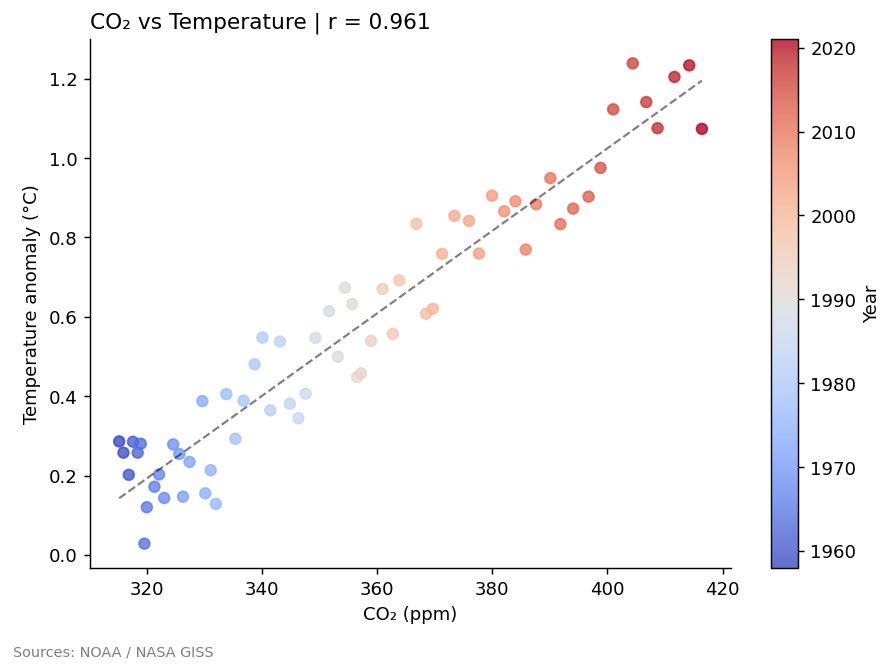

In [16]:
annual_co2 = co2_df.assign(year = co2_df['date'].dt.year).groupby('year')['co2_ppm'].mean().reset_index()
merged = pd.merge(annual_temp, annual_co2, on = 'year').dropna()
corr = merged['anomaly_C'].corr(merged['co2_ppm'])

m_c, b_c, _, _, _ = stats.linregress(merged['co2_ppm'], merged['anomaly_C'])
x_line = np.linspace(merged['co2_ppm'].min(), merged['co2_ppm'].max(), 100)

fig, ax = plt.subplots(figsize = (7, 5))

scatter = ax.scatter(merged['co2_ppm'], merged['anomaly_C'], c = merged['year'], cmap = 'coolwarm', s = 35, alpha = 0.8)
ax.plot(x_line, m_c * x_line + b_c, color = 'black', linewidth = 1.2, linestyle = '--', alpha = 0.5)
ax.set_xlabel('CO₂ (ppm)')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_title(f'CO₂ vs Temperature | r = {corr:.3f}', loc = 'left')

plt.colorbar(scatter, ax = ax, label = 'Year')
plt.figtext(0.01, -0.02, 'Sources: NOAA / NASA GISS', fontsize = 8, color = 'gray')
plt.tight_layout()
plt.show()

In [17]:
merged['residual'] = merged['anomaly_C'] - (m_c * merged['co2_ppm'] + b_c)
warm_yrs = sorted(merged.nlargest(3, 'residual')['year'].tolist())
cool_yrs = sorted(merged.nsmallest(3, 'residual')['year'].tolist())
per_100ppm = m_c * 100

Markdown(f"""
Annual CO\u2082 and global temperature correlate at **r = {corr:.3f}** across {len(merged)}
overlapping years, with a fitted slope of about **+{per_100ppm:.2f}\u00b0C per 100 ppm**. Colour
runs blue (earlier decades) to red (recent), and both variables climb together throughout.

The residuals are worth a look. The warmest years for their CO\u2082 level,
**{', '.join(map(str, warm_yrs))}**, are all strong El Ni\u00f1o years, when the Pacific releases
stored heat to the atmosphere. The coolest, **{', '.join(map(str, cool_yrs))}**, line up with
volcanic aerosol loading and La Ni\u00f1a.
""")


Annual CO₂ and global temperature correlate at **r = 0.961** across 64
overlapping years, with a fitted slope of about **+1.04°C per 100 ppm**. Colour
runs blue (earlier decades) to red (recent), and both variables climb together throughout.

The residuals are worth a look. The warmest years for their CO₂ level,
**1981, 1998, 2016**, are all strong El Niño years, when the Pacific releases
stored heat to the atmosphere. The coolest, **1964, 1974, 1976**, line up with
volcanic aerosol loading and La Niña.


In [18]:
example_score = min(current_temp / 2.0 * 100, 100)

Markdown(f"""
### Tipping Points & Proximity Scores

Thresholds are from **Table 1, Armstrong McKay et al. (2022)**, *Science*, Vol. 377, DOI:
10.1126/science.abn7950, expressed as global mean surface temperature above the 1850\u20131900
baseline (why the GISS series was re-referenced earlier).

**Proximity score:** `score = (current warming / threshold) * 100`. 0 = pre-industrial,
100 = threshold reached.

At **+{current_temp:.2f}\u00b0C**, an element with a 2.0\u00b0C threshold scores
**{example_score:.0f}**. This is a constructed index, not a physical quantity: it measures
distance in degrees, not likelihood of tipping.

Each element's lower/upper bounds reflect real scientific disagreement over where the
threshold sits, not measurement error; the error bars below span the resulting score range.
""")


### Tipping Points & Proximity Scores

Thresholds are from **Table 1, Armstrong McKay et al. (2022)**, *Science*, Vol. 377, DOI:
10.1126/science.abn7950, expressed as global mean surface temperature above the 1850–1900
baseline (why the GISS series was re-referenced earlier).

**Proximity score:** `score = (current warming / threshold) * 100`. 0 = pre-industrial,
100 = threshold reached.

At **+1.07°C**, an element with a 2.0°C threshold scores
**54**. This is a constructed index, not a physical quantity: it measures
distance in degrees, not likelihood of tipping.

Each element's lower/upper bounds reflect real scientific disagreement over where the
threshold sits, not measurement error; the error bars below span the resulting score range.


In [19]:
# define tipping point thresholds

TIPPING_POINTS = {
    'Greenland Ice Sheet': {
        'code': 'GrIS',
        'category': 'Global core',
        'threshold': 1.5,
        'threshold_min': 0.8,
        'threshold_max': 3.0,
        'timescale_est': 10000,
        'consequence': 'Up to 7m sea level rise over millennia',
    },
    'W. Antarctic Ice Sheet': {
        'code': 'WAIS',
        'category': 'Global core',
        'threshold': 1.5,
        'threshold_min': 1.0,
        'threshold_max': 3.0,
        'timescale_est': 2000,
        'consequence': 'Up to 5m additional sea level rise',
    },
    'Labrador Sea Convection': {
        'code': 'LABC',
        'category': 'Global core',
        'threshold': 1.8,
        'threshold_min': 1.1,
        'threshold_max': 3.8,
        'timescale_est': 10,
        'consequence': 'Regional cooling -3°C, disrupted ocean circulation',
    },
    'E. Antarctic Subglacial Basins': {
        'code': 'EASB',
        'category': 'Global core',
        'threshold': 3.0,
        'threshold_min': 2.0,
        'threshold_max': 6.0,
        'timescale_est': 2000,
        'consequence': 'Significant additional sea level rise',
    },
    'Amazon Rainforest': {
        'code': 'AMAZ',
        'category': 'Global core',
        'threshold': 3.5,
        'threshold_min': 2.0,
        'threshold_max': 6.0,
        'timescale_est': 100,
        'consequence': 'Dieback releases 30-75 GtC, regional rainfall collapse',
    },
    'Boreal Permafrost': {
        'code': 'PFTP',
        'category': 'Global core',
        'threshold': 4.0,
        'threshold_min': 3.0,
        'threshold_max': 6.0,
        'timescale_est': 50,
        'consequence': '125-250 GtC released, +0.2-0.4°C additional warming',
    },
    'AMOC Collapse': {
        'code': 'AMOC',
        'category': 'Global core',
        'threshold': 4.0,
        'threshold_min': 1.4,
        'threshold_max': 8.0,
        'timescale_est': 50,
        'consequence': '-4 to -10°C regional cooling, monsoon disruption',
    },
    'Arctic Winter Sea Ice': {
        'code': 'AWSI',
        'category': 'Global core',
        'threshold': 6.3,
        'threshold_min': 4.5,
        'threshold_max': 8.7,
        'timescale_est': 20,
        'consequence': '+0.6°C global warming, +0.6-1.2°C regional',
    },
    'E. Antarctic Ice Sheet': {
        'code': 'EAIS',
        'category': 'Global core',
        'threshold': 7.5,
        'threshold_min': 5.0,
        'threshold_max': 10.0,
        'timescale_est': 10000,
        'consequence': '+0.6°C global, +2°C regional warming',
    },
    'Low-latitude Coral Reefs': {
        'code': 'REEF',
        'category': 'Regional impact',
        'threshold': 1.5,
        'threshold_min': 1.0,
        'threshold_max': 2.0,
        'timescale_est': 10,
        'consequence': 'Die-off, 500M people lose coastal protection and food',
    },
    'Boreal Permafrost (abrupt thaw)': {
        'code': 'PFAT',
        'category': 'Regional impact',
        'threshold': 1.5,
        'threshold_min': 1.0,
        'threshold_max': 2.3,
        'timescale_est': 200,
        'consequence': 'Adds 50% to gradual thaw, 10 GtC/°C by 2100',
    },
    'Barents Sea Ice': {
        'code': 'BARI',
        'category': 'Regional impact',
        'threshold': 1.6,
        'threshold_min': 1.5,
        'threshold_max': 1.7,
        'timescale_est': 25,
        'consequence': 'Abrupt Arctic sea ice loss, regional climate shift',
    },
    'Mountain Glaciers': {
        'code': 'GLCR',
        'category': 'Regional impact',
        'threshold': 2.0,
        'threshold_min': 1.5,
        'threshold_max': 3.0,
        'timescale_est': 200,
        'consequence': '+0.08°C global, freshwater loss for millions',
    },
    'Sahel & W. African Monsoon': {
        'code': 'SAHL',
        'category': 'Regional impact',
        'threshold': 2.8,
        'threshold_min': 2.0,
        'threshold_max': 3.5,
        'timescale_est': 50,
        'consequence': 'Greening of Sahel, major rainfall pattern shift',
    },
    'Boreal Forest (dieback)': {
        'code': 'BORF',
        'category': 'Regional impact',
        'threshold': 4.0,
        'threshold_min': 1.4,
        'threshold_max': 5.0,
        'timescale_est': 100,
        'consequence': '-0.18°C global, -0.5 to -2°C regional cooling',
    },
    'Boreal Forest (expansion)': {
        'code': 'TUND',
        'category': 'Regional impact',
        'threshold': 4.0,
        'threshold_min': 1.5,
        'threshold_max': 7.2,
        'timescale_est': 100,
        'consequence': '+0.14°C global, +0.5-1.0°C regional warming',
    },
}

In [20]:
# compute proximity scores

def compute_proximity_score(current, threshold):
    """
    Score of 0 is the pre-industrial baseline (1880-1899 mean),
    100 means the threshold has been reached or passed.
    Capped at 100 so a crossed element does not run off the scale.
    """
    return round(min((current / threshold) * 100, 100), 1)

results = []
for name, info in TIPPING_POINTS.items():
    distance = round(info['threshold'] - current_temp, 2)
    score = compute_proximity_score(current_temp, info['threshold'])
    years_left = round(distance / warming_per_year) if distance > 0 else 0

    results.append({
        'name': name,
        'code': info['code'],
        'category': info['category'],
        'threshold': info['threshold'],
        'threshold_min': info['threshold_min'],
        'threshold_max': info['threshold_max'],
        'distance': distance,
        'proximity_score': score,
        'years_remaining': years_left,
        'crossed': distance <= 0,
        'consequence': info['consequence'],
    })

results_df = pd.DataFrame(results).sort_values('distance').reset_index(drop = True)

display(
    results_df[['name', 'category', 'threshold', 'distance', 'proximity_score', 'years_remaining']]
    .style
    .format({'threshold': '{:.1f}', 'distance': '{:+.2f}', 'proximity_score': '{:.1f}'})
    .background_gradient(subset = ['proximity_score'], cmap = 'YlOrRd', vmin = 0, vmax = 100)
    .set_caption(f'Proximity to tipping thresholds at +{current_temp:.2f}°C above pre-industrial')
)

,name,category,threshold,distance,proximity_score,years_remaining
0,Greenland Ice Sheet,Global core,1.5,+0.43,71.6,21
1,W. Antarctic Ice Sheet,Global core,1.5,+0.43,71.6,21
2,Low-latitude Coral Reefs,Regional impact,1.5,+0.43,71.6,21
3,Boreal Permafrost (abrupt thaw),Regional impact,1.5,+0.43,71.6,21
4,Barents Sea Ice,Regional impact,1.6,+0.53,67.1,25
5,Labrador Sea Convection,Global core,1.8,+0.73,59.7,35
6,Mountain Glaciers,Regional impact,2.0,+0.93,53.7,45
7,Sahel & W. African Monsoon,Regional impact,2.8,+1.73,38.3,83
8,E. Antarctic Subglacial Basins,Global core,3.0,+1.93,35.8,93
9,Amazon Rainforest,Global core,3.5,+2.43,30.7,117


In [21]:
years_df = results_df.sort_values('proximity_score', ascending = True).copy()

years_df['urgency'] = years_df.apply(
    lambda row: 'Threshold crossed' if row['crossed']
    else '≥ 80% (Critical)' if row['proximity_score'] >= 80
    else '60–80% (High)' if row['proximity_score'] >= 60
    else '40–60% (Moderate)' if row['proximity_score'] >= 40
    else '< 40% (Low)',
    axis = 1
)

# compute proximity scores for uncertainty bounds
years_df['proximity_score_low'] = years_df['threshold_max'].apply(
    lambda t: round(min((current_temp / t) * 100, 100), 1)
)
years_df['proximity_score_high'] = years_df['threshold_min'].apply(
    lambda t: round(min((current_temp / t) * 100, 100), 1)
)

urgency_order = ['Threshold crossed', '≥ 80% (Critical)', '60–80% (High)', '40–60% (Moderate)', '< 40% (Low)']
urgency_colors = ['darkred', 'red', 'darkorange', 'gold', 'green']
name_order = years_df['name'].tolist()

# main bars
bars = alt.Chart(years_df).mark_bar(height = 18).encode(
    y = alt.Y('name:N', sort = name_order, title = None),
    x = alt.X('proximity_score:Q',
              title = 'Proximity score % (0 = pre-industrial, 100 = threshold reached)',
              scale = alt.Scale(domain = [0, 100])),
    color = alt.Color('urgency:N', sort = urgency_order,
                      scale = alt.Scale(domain = urgency_order, range = urgency_colors),
                      legend = alt.Legend(title = 'Urgency')),
    tooltip = [
        alt.Tooltip('name:N', title = 'Tipping Element'),
        alt.Tooltip('category:N', title = 'Category'),
        alt.Tooltip('distance:Q', title = '°C remaining'),
        alt.Tooltip('proximity_score:Q', title = 'Proximity score (%)'),
        alt.Tooltip('years_remaining:Q', title = 'Years remaining (~)'),
        alt.Tooltip('consequence:N', title = 'Consequence'),
    ]
)

# error bars
error_bars = alt.Chart(years_df).mark_errorbar(
    ticks = True, color = 'black', opacity = 0.45
).encode(
    y = alt.Y('name:N', sort = name_order),
    x = alt.X('proximity_score_low:Q',
              scale = alt.Scale(domain = [0, 100]),
              title = 'Proximity score % (0 = pre-industrial, 100 = threshold reached)'),
    x2 = alt.X2('proximity_score_high:Q'),
)

proximity_chart = (bars + error_bars).properties(
    width = 700,
    height = 420,
    title = 'Climate Tipping Point Proximity Scores',
    padding = {'top': 10, 'bottom': 100, 'left': 10, 'right': 10}
).configure_view(strokeWidth = 0)

proximity_chart

alt.LayerChart(...)

### Probabilistic Crossing Dates

The scores above use each element's best-estimate threshold. Armstrong McKay et al. publish a
range, and the warming rate carries its own regression uncertainty. Propagating both through a
Monte Carlo turns proximity into probability: not how close we are, but the odds of crossing
by 2050.

In [22]:
rng = np.random.default_rng(42)
N_SIMS = 20_000
CURRENT_YEAR = int(annual_temp['year'].max())
HORIZON = 2200

mc_records, crossing_samples = [], {}

for name, info in TIPPING_POINTS.items():
    # threshold uncertainty: triangular over (min, best, max) from Armstrong McKay Table 1
    thresholds = rng.triangular(info['threshold_min'], info['threshold'],
                                info['threshold_max'], N_SIMS)
    # rate uncertainty: normal around the post-1980 OLS slope, sd = its standard error
    rates = rng.normal(warming_per_year, stderr, N_SIMS)

    gap = thresholds - current_temp
    with np.errstate(divide = 'ignore', invalid = 'ignore'):
        years_to = np.where(gap <= 0, 0.0, gap / rates)
    years_to = np.where((gap > 0) & (rates <= 0), np.inf, years_to)   # sampled cooling never crosses
    cross_yr = CURRENT_YEAR + years_to
    crossing_samples[name] = cross_yr

    q05, q50, q95 = np.percentile(np.minimum(cross_yr, HORIZON), [5, 50, 95])
    mc_records.append({
        'name': name, 'code': info['code'], 'category': info['category'],
        'p_already': (gap <= 0).mean(),
        'p_2050': (cross_yr <= 2050).mean(),
        'p_2100': (cross_yr <= 2100).mean(),
        'median_year': q50, 'ci_lo': q05, 'ci_hi': q95,
    })

mc_df = pd.DataFrame(mc_records).sort_values('p_2100', ascending = False).reset_index(drop = True)

display(
    mc_df[['name', 'category', 'p_already', 'p_2050', 'p_2100', 'median_year', 'ci_lo', 'ci_hi']]
    .style
    .format({'p_already': '{:.0%}', 'p_2050': '{:.0%}', 'p_2100': '{:.0%}',
             'median_year': '{:.0f}', 'ci_lo': '{:.0f}', 'ci_hi': '{:.0f}'})
    .background_gradient(subset = ['p_2050', 'p_2100'], cmap = 'YlOrRd', vmin = 0, vmax = 1)
    .set_caption(f'Monte Carlo crossing probabilities · {N_SIMS:,} draws · '
                 f'current warming +{current_temp:.2f}°C · rate {warming_per_year:.4f} ± {stderr:.4f} °C/yr')
)

,name,category,p_already,p_2050,p_2100,median_year,ci_lo,ci_hi
0,Low-latitude Coral Reefs,Regional impact,1%,67%,100%,2045,2029,2062
1,Boreal Permafrost (abrupt thaw),Regional impact,1%,52%,100%,2049,2030,2074
2,Barents Sea Ice,Regional impact,0%,47%,100%,2050,2046,2055
3,Greenland Ice Sheet,Global core,5%,40%,95%,2056,2025,2099
4,W. Antarctic Ice Sheet,Global core,1%,34%,95%,2059,2032,2100
5,Mountain Glaciers,Regional impact,0%,1%,90%,2076,2055,2106
6,Labrador Sea Convection,Global core,0%,13%,75%,2077,2041,2133
7,Sahel & W. African Monsoon,Regional impact,0%,0%,35%,2106,2080,2134
8,Boreal Forest (dieback),Regional impact,0%,0%,16%,2144,2073,2198
9,E. Antarctic Subglacial Basins,Global core,0%,0%,11%,2144,2090,2200


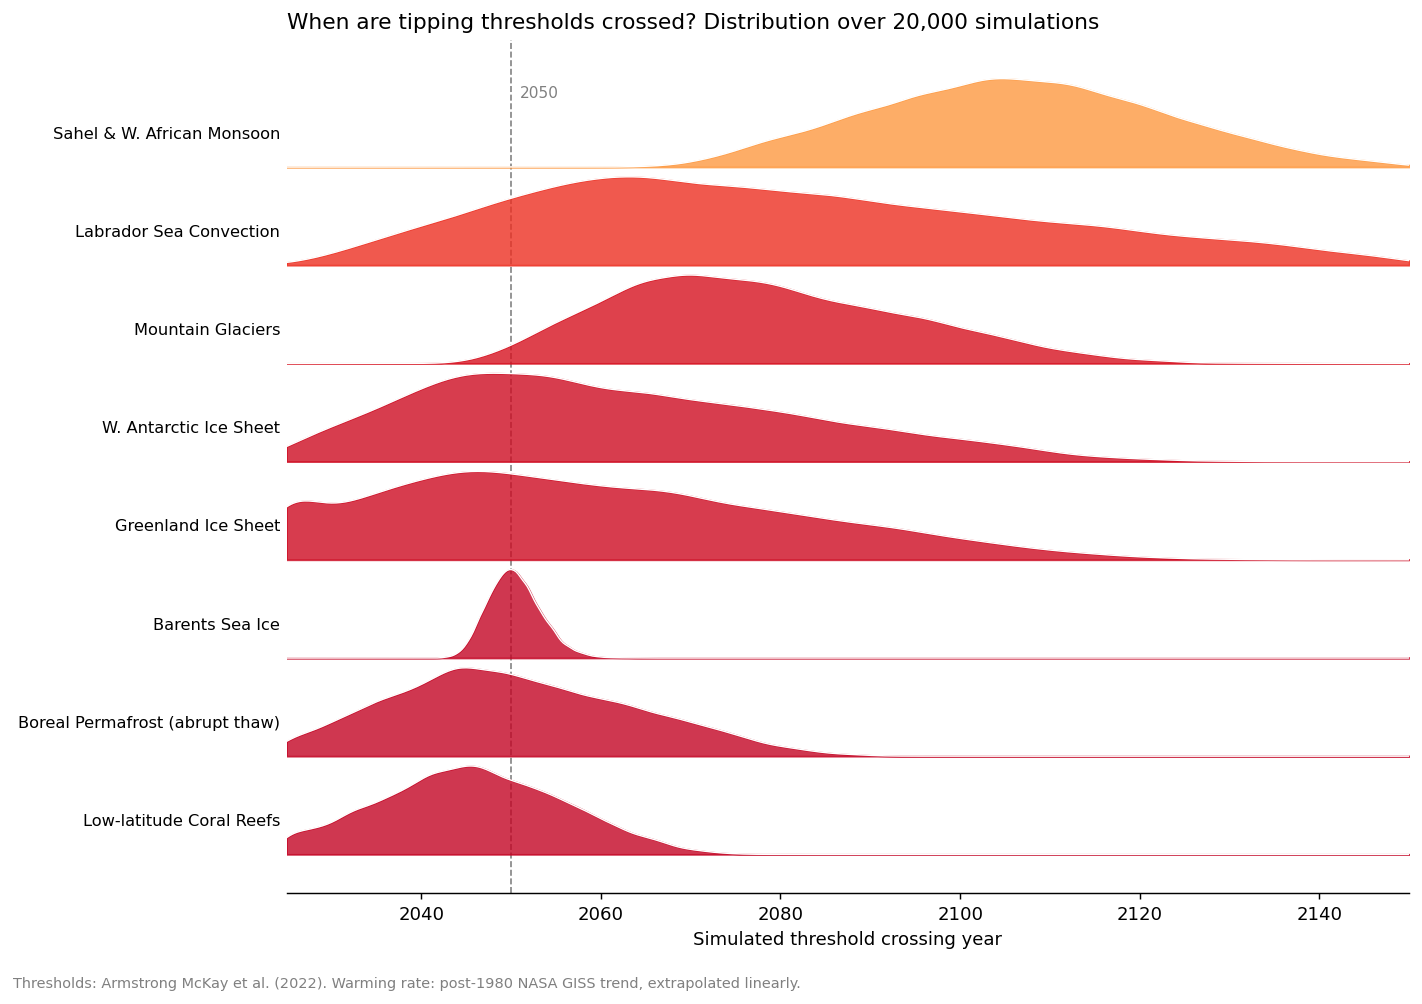

In [23]:
PLOT_MAX = 2150
ranked = mc_df[mc_df['p_2100'] > 0.01].nsmallest(8, 'median_year')

fig, ax = plt.subplots(figsize = (11, 0.75 * len(ranked) + 1.5))
cmap = plt.get_cmap('YlOrRd')

for i, row in enumerate(ranked.itertuples()):
    samples = crossing_samples[row.name]
    finite = samples[np.isfinite(samples) & (samples <= PLOT_MAX)]
    if len(finite) < 50:
        continue
    shade = cmap(0.25 + 0.6 * row.p_2100)
    if np.std(finite) < 1e-6:                      # all mass on one year, KDE would fail
        ax.vlines(finite[0], i, i + 0.9, color = shade, linewidth = 3)
        continue
    kde = stats.gaussian_kde(finite)
    xs = np.linspace(CURRENT_YEAR, PLOT_MAX, 500)
    ys = kde(xs)
    ys = ys / ys.max() * 0.9
    ax.fill_between(xs, i, i + ys, color = shade, alpha = 0.8, zorder = 3 - i * 0.1)
    ax.plot(xs, i + ys, color = 'white', linewidth = 0.8, zorder = 3 - i * 0.1)

ax.axvline(2050, color = 'black', linestyle = '--', linewidth = 0.9, alpha = 0.5)
ax.text(2051, len(ranked) - 0.3, '2050', fontsize = 8.5, color = 'gray')
ax.set_yticks(np.arange(len(ranked)) + 0.35)
ax.set_yticklabels(ranked['name'], fontsize = 9)
ax.set_xlim(CURRENT_YEAR, PLOT_MAX)
ax.set_xlabel('Simulated threshold crossing year')
ax.set_title('When are tipping thresholds crossed? Distribution over 20,000 simulations',
             loc = 'left')
ax.spines['left'].set_visible(False)
ax.tick_params(axis = 'y', length = 0)

plt.figtext(0.01, -0.02, 'Thresholds: Armstrong McKay et al. (2022). '
                         'Warming rate: post-1980 NASA GISS trend, extrapolated linearly.',
            fontsize = 8, color = 'gray')
plt.tight_layout()
plt.show()

In [24]:
near_certain = mc_df[mc_df['p_2050'] >= 0.9]
likely_2100 = mc_df[mc_df['p_2100'] >= 0.5]
already = mc_df[mc_df['p_already'] >= 0.5]
already_txt = f" ({', '.join(already['code'])})" if len(already) else ""

Markdown(f"""
Propagating threshold and rate uncertainty through {N_SIMS:,} simulations sharpens the point
estimates. **{len(already)} of {len(mc_df)}** elements are more likely than not to have
*already* passed their threshold{already_txt}. **{len(near_certain)}** cross before 2050 at
\u226590% probability; **{len(likely_2100)}** are more likely than not to cross this century.

Spread matters as much as median. Barents Sea Ice has a narrow distribution (tight published
bounds); AMOC spans a century-plus because its bounds (1.4\u20138.0\u00b0C) reflect real
disagreement about the physics. A wide distribution isn't reassuring: the early tail stays
live even when the median looks distant.

Four things this doesn't resolve: the triangular distribution is a convenience (true shape
unknown), rate uncertainty covers only OLS fit error, not the much larger emissions-pathway
uncertainty, elements are simulated independently despite documented interactions (e.g.
Greenland meltwater destabilizing AMOC), and crossing a threshold isn't tipping, since
transition timescales range from a decade to ten millennia.
""")


Propagating threshold and rate uncertainty through 20,000 simulations sharpens the point
estimates. **0 of 16** elements are more likely than not to have
*already* passed their threshold. **0** cross before 2050 at
≥90% probability; **7** are more likely than not to cross this century.

Spread matters as much as median. Barents Sea Ice has a narrow distribution (tight published
bounds); AMOC spans a century-plus because its bounds (1.4–8.0°C) reflect real
disagreement about the physics. A wide distribution isn't reassuring: the early tail stays
live even when the median looks distant.

Four things this doesn't resolve: the triangular distribution is a convenience (true shape
unknown), rate uncertainty covers only OLS fit error, not the much larger emissions-pathway
uncertainty, elements are simulated independently despite documented interactions (e.g.
Greenland meltwater destabilizing AMOC), and crossing a threshold isn't tipping, since
transition timescales range from a decade to ten millennia.


In [25]:
n_total = len(results_df)
n_crossed = int(results_df['crossed'].sum())
n_near = int(((results_df['distance'] > 0) & (results_df['distance'] <= 0.5)).sum())

core_risk = mc_df[(mc_df['category'] == 'Global core') & (mc_df['p_2100'] >= 0.5)]
soonest = mc_df.nsmallest(1, 'median_year').iloc[0]

# recent-decade rates
co2_recent = co2_df[co2_df['date'].dt.year >= co2_df['date'].dt.year.max() - 10]
co2_rate = np.polyfit(co2_recent['date'].dt.year + co2_recent['date'].dt.month / 12,
                      co2_recent['co2_ppm'], 1)[0]
ice_rate = fit_lin.params[1] * 10

window_gap = abs(current_temp_2yr - current_temp)
window_dir = 'higher' if current_temp_2yr > current_temp else 'lower'

Markdown(f"""
## Findings

1. Current warming: +{current_temp:.2f}\u00b0C above pre-industrial ({WINDOW_YEARS}-yr mean).
   Two choices drive this number: the 1951\u20131980 baseline shift ({PI_BASELINE:+.2f}\u00b0C
   offset) and the averaging window. The window matters more: a 2-year window reads
   +{current_temp_2yr:.2f}\u00b0C ({window_gap:.2f}\u00b0C {window_dir}) from sitting on the
   2023\u201324 El Ni\u00f1o. Everything below inherits both.

2. {n_crossed} of {n_total} elements are at or past their best-estimate threshold, {n_near}
   more within 0.5\u00b0C. Nearest cluster at 1.5\u00b0C: Greenland, West Antarctica, coral
   reefs, abrupt permafrost thaw.

3. Warming: {warming_per_year * 10:.2f} \u00b1 {stderr * 10:.2f}\u00b0C/decade since 1980
   (R\u00b2 = {r**2:.2f}). Held constant, +1.5\u00b0C arrives ~{crossing_year(1.5):.0f},
   +2.0\u00b0C ~{crossing_year(2.0):.0f}.

4. CO\u2082: {current_co2:.0f} ppm, +{current_co2 - 280:.0f} ppm vs pre-industrial, rising
   {co2_rate:.1f} ppm/yr over the past decade, r = {corr:.2f} with temperature.

5. Arctic September sea ice: losing {abs(ice_rate):.2f} million km\u00b2/decade. Tested for
   ice-albedo acceleration; quadratic term is indistinguishable from zero (p = {p_quad:.2f})
   and lowers adjusted r\u00b2. Decline is steady over this record; the extrapolated ice-free
   date is not a projection.

6. Monte Carlo: {len(core_risk)} global-core elements more likely than not to cross this
   century, earliest *{soonest['name']}* at median {soonest['median_year']:.0f}. Threshold
   uncertainty dominates the spread over rate uncertainty; narrowing thresholds would tighten
   these distributions more than a better warming-rate estimate.
""")


## Findings

1. Current warming: +1.07°C above pre-industrial (20-yr mean).
   Two choices drive this number: the 1951–1980 baseline shift (-0.23°C
   offset) and the averaging window. The window matters more: a 2-year window reads
   +1.46°C (0.39°C higher) from sitting on the
   2023–24 El Niño. Everything below inherits both.

2. 0 of 16 elements are at or past their best-estimate threshold, 4
   more within 0.5°C. Nearest cluster at 1.5°C: Greenland, West Antarctica, coral
   reefs, abrupt permafrost thaw.

3. Warming: 0.21 ± 0.02°C/decade since 1980
   (R² = 0.87). Held constant, +1.5°C arrives ~2036,
   +2.0°C ~2060.

4. CO₂: 429 ppm, +149 ppm vs pre-industrial, rising
   2.5 ppm/yr over the past decade, r = 0.96 with temperature.

5. Arctic September sea ice: losing 0.78 million km²/decade. Tested for
   ice-albedo acceleration; quadratic term is indistinguishable from zero (p = 0.78)
   and lowers adjusted r². Decline is steady over this record; the extrapolated ice-free
   date is not a projection.

6. Monte Carlo: 3 global-core elements more likely than not to cross this
   century, earliest *Low-latitude Coral Reefs* at median 2045. Threshold
   uncertainty dominates the spread over rate uncertainty; narrowing thresholds would tighten
   these distributions more than a better warming-rate estimate.


## Limitations

**Baseline conversion.** GISTEMP starts in 1880, used as a stand-in for the 1850-1900
IPCC/Armstrong McKay reference. Residual offset ~0.03-0.05°C, biasing every score slightly
low.

**Averaging window.** Current warming uses a 20-year mean (IPCC AR6 convention). A 2-year
window reads 0.39°C higher here, more than the baseline offset, because it sits on the
2023-24 El Niño. Every score and crossing date depends on this choice.

**GMST as a single control parameter.** Thresholds are expressed as GMST, but the underlying
systems respond to regional forcing, ocean heat content, freshwater flux and rate of change.
Two paths to +2°C don't carry the same tipping risk.

**Linear rate extrapolation.** Crossing dates assume the post-1980 trend holds, ignoring
committed warming, carbon-cycle feedbacks, aerosol masking and policy change. Notebook 02
backtests this and finds the linear fit runs ~0.12°C low at a 10-year horizon (~6 years),
so these dates are probably late.

**Crossing ≠ tipping.** Transition timescales range from a decade (Labrador Sea) to ten
millennia (Greenland, East Antarctica). Crossing a threshold commits a system without
producing visible effects soon after.

**Independence assumption.** Elements are modeled separately, but interactions are documented
(e.g. Greenland meltwater destabilizing AMOC, shifting Amazon rainfall). Cascades would push
joint probabilities above the product of the marginals.

**Single-source observations.** One dataset per variable; no ensemble spread from HadCRUT5,
Berkeley Earth or NOAA GlobalTemp, and GISTEMP's own uncertainty (Lenssen et al. 2019) isn't
in the Monte Carlo.

**Distributional assumption.** Triangular threshold distribution is a convenience; the source
gives ranges, not distributions, and true shapes are unknown.

## References

**Tipping point thresholds**
Armstrong McKay, D.I., Staal, A., Abrams, J.F., Winkelmann, R., Sakschewski, B., Loriani, S.,
Fetzer, I., Cornell, S.E., Rockström, J., Lenton, T.M. (2022). Exceeding 1.5°C global warming
could trigger multiple climate tipping points. *Science*, 377(6611), eabn7950.
DOI: 10.1126/science.abn7950. Thresholds from Table 1.

**Global temperature**
GISTEMP Team. GISS Surface Temperature Analysis (GISTEMP), version 4. NASA Goddard Institute
for Space Studies. data.giss.nasa.gov/gistemp/. Access dates for each dataset are printed by
the final cell of this notebook.
Lenssen, N., Schmidt, G., Hansen, J., Menne, M., Persin, A., Ruedy, R., Zyss, D. (2019).
Improvements in the GISTEMP uncertainty model. *J. Geophys. Res. Atmos.*, 124(12), 6307–6326.
DOI: 10.1029/2018JD029522.

**Atmospheric CO₂**
Lan, X., Tans, P., Thoning, K.W. Trends in globally-averaged CO₂ determined from NOAA Global
Monitoring Laboratory measurements. NOAA GML, Mauna Loa Observatory monthly means.
gml.noaa.gov/ccgg/trends/

**Arctic sea ice**
Fetterer, F., Knowles, K., Meier, W.N., Savoie, M., Windnagel, A.K. (2017, updated daily).
Sea Ice Index, Version 3. NSIDC, Boulder, Colorado. DOI: 10.7265/N5K072F8.
Retrieved via Our World in Data, ourworldindata.org/grapher/monthly-sea-ice-extent-in-the-arctic

**Methods**
Newey, W.K., West, K.D. (1987). A simple, positive semi-definite, heteroskedasticity and
autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708.
DOI: 10.2307/1913610.

**Context**
IPCC (2021). *Climate Change 2021: The Physical Science Basis.* Working Group I contribution to
the Sixth Assessment Report. Cambridge University Press. DOI: 10.1017/9781009157896.

In [26]:
def accessed(filename):
    path = DATA_DIR / filename
    return (pd.Timestamp(path.stat().st_mtime, unit = 's').strftime('%Y-%m-%d')
            if path.exists() else 'not cached')

for f in ['global_temp.csv', 'co2_mm_mlo.csv', 'arctic_sea_ice.csv']:
    print(f'{f:24} accessed {accessed(f)}')

global_temp.csv          accessed 2026-08-08
co2_mm_mlo.csv           accessed 2026-08-08
arctic_sea_ice.csv       accessed 2026-08-08


In [27]:
import json
from datetime import date

OUT_DIR = Path('dashboard_data')
OUT_DIR.mkdir(exist_ok = True)

results_df.to_csv(OUT_DIR / 'proximity.csv', index = False)
mc_df.to_csv(OUT_DIR / 'monte_carlo.csv', index = False)
annual_temp[['year', 'anomaly_C', 'rolling_10yr']].to_csv(
    OUT_DIR / 'annual_temp.csv', index = False)

summary = {
    'generated': date.today().isoformat(),
    'current_year': int(CURRENT_YEAR),
    'window_years': int(WINDOW_YEARS),
    'current_temp': round(float(current_temp), 3),
    'current_temp_2yr': round(float(current_temp_2yr), 3),
    'pi_baseline': round(float(PI_BASELINE), 3),
    'warming_per_decade': round(float(warming_per_year * 10), 4),
    'stderr_per_decade': round(float(stderr * 10), 4),
    'current_co2': round(float(current_co2), 1),
    'ice_rate': round(float(ice_rate), 3),
    'n_total': int(n_total),
    'n_crossed': int(n_crossed),
    'n_near': int(n_near),
    'year_1p5': int(round(crossing_year(1.5))),
    'year_2p0': int(round(crossing_year(2.0))),
    'n_sims': int(N_SIMS),
    'accessed': {f: accessed(f) for f in
                 ['global_temp.csv', 'co2_mm_mlo.csv', 'arctic_sea_ice.csv']},
}
(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent = 2))

print(f'wrote {len(list(OUT_DIR.iterdir()))} files to {OUT_DIR}/')

wrote 4 files to dashboard_data/
